### kNN

In [1]:
import pandas as pd

In [2]:
# 데이터 불러오기
train = pd.read_csv("../Data/basketball_train.csv")
test = pd.read_csv("../Data/basketball_test.csv")

In [3]:
# 전체 갯수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  80 non-null     str    
 1   Pos     80 non-null     str    
 2   3P      80 non-null     float64
 3   TRB     80 non-null     float64
 4   BLK     80 non-null     float64
dtypes: float64(3), str(2)
memory usage: 3.3 KB


In [5]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  20 non-null     str    
 1   Pos     20 non-null     str    
 2   3P      20 non-null     float64
 3   TRB     20 non-null     float64
 4   BLK     20 non-null     float64
dtypes: float64(3), str(2)
memory usage: 932.0 bytes


#### 최적의 k 찾기와 교차검증 ( Cross Validation )

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [7]:
# 최적의 k를 찾기 위해 교차검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = train.shape[0] // 2

In [8]:
# 최적의 k를 찾기 위한 범위 확인
k_list = [i for i in range(3, max_k_range, 2)]
k_list

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [9]:
train_data = train[['3P', 'BLK', 'TRB']]
train_target = train['Pos']

In [10]:
# 교차검증(10 fold)을 각 k를 대상으로 수행해 검증결과를 저장
cross_validation_scores = []
for k in k_list :
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        train_data,
        train_target,
        cv = 10,        # cross validation : 9개는 학습용, 1개는 검증용
        scoring = 'accuracy'
    )

    print(k, ":", scores)
    cross_validation_scores.append(scores.mean())

3 : [0.875 0.875 0.875 0.875 0.875 0.875 0.75  1.    1.    0.75 ]
5 : [0.875 0.75  0.875 0.875 1.    1.    0.75  1.    1.    0.875]
7 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
9 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
11 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
13 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
15 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
17 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
19 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
21 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
23 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
25 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
27 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
29 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
31 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]

In [11]:
print(cross_validation_scores)

[np.float64(0.875), np.float64(0.9), np.float64(0.875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.875), np.float64(0.875), np.float64(0.8625), np.float64(0.85), np.float64(0.8375), np.float64(0.8375)]


In [12]:
import matplotlib.pyplot as plt

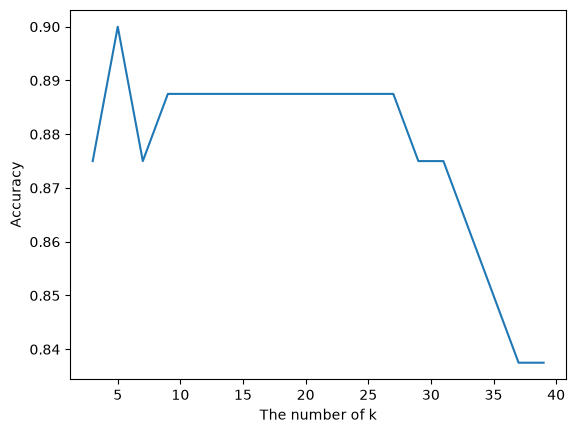

In [13]:
# k의 정확도 시각화
plt.plot(
    k_list,
    cross_validation_scores
)

plt.xlabel("The number of k")
plt.ylabel("Accuracy")
plt.show()

In [14]:
# 가장 예측율이 높은 k를 선정
k_list[cross_validation_scores.index(max(cross_validation_scores))]

5

#### 2개의 특징으로 예측 (3점슛, 블로킹)

In [15]:
# Model
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
# Feature
train_data = train_data[['3P', 'BLK']]

In [17]:
# Target
train_target = train['Pos']

In [18]:
import sklearn
sklearn.set_config(display="text")

from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model

KNeighborsClassifier()

In [19]:
# 학습시키기
knn.fit(train_data, train_target)

KNeighborsClassifier()

In [20]:
test_data = test[['3P', 'BLK']]
test_target = test['Pos']

In [21]:
# 평가
print("Train :", knn.score(train_data, train_target) )
print("Test :", knn.score(test_data, test_target) )

Train : 0.9625
Test : 0.95


#### 3개의 특징으로 예측 (3점슛, 블로킹, 리바운드)

In [28]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=5)

test_data = test[['3P', 'BLK', 'TRB']]
test_target = test['Pos']

knn.fit(test_data, test_target)

print("Test Score :", knn.score(test_data, test_target))

Test Score : 0.95


#### 학습한 AI Model 사용
어떤 선수의 점수가 아래와 같은 경우 포지션 추천
- 3P : 3.4
- BLK : 0.5
- TRB : 3.7

In [ ]:
train_data

,3P,BLK
0,0.9,1.1
1,1.8,0.4
2,1.7,0.3
3,1.3,0.2
4,1.7,0.8
...,...,...
75,0.0,0.7
76,0.0,0.8
77,1.9,0.3
78,0.0,1.3
